# 05. CatBoost 최종 모델 (Optuna 튜닝)

`04_model_comparison`에서 최고 성능을 보인 **CatBoost**에 Optuna 하이퍼파라미터 튜닝을 적용하여 최종 모델을 완성합니다.

## 내용
1. Optuna를 이용한 하이퍼파라미터 최적화 (검증셋 ROC-AUC 기준)
2. 최적 모델 학습 및 테스트셋 평가
3. Feature Importance 분석
4. 혼동 행렬 (Confusion Matrix)
5. ROC Curve

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
import optuna
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report,
                             roc_curve, precision_score, recall_score)
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

SEED = 42

## 1. 데이터 로드

In [2]:
DATA = '../data/processed'

def load(split):
    X = pd.read_csv(f'{DATA}/{split}_features.csv', encoding='utf-8-sig')
    y = pd.read_csv(f'{DATA}/{split}_target.csv', encoding='utf-8-sig').iloc[:, 0].values
    return X, y

X_train, y_train = load('train')
X_val, y_val = load('val')
X_test, y_test = load('test')

cat_idx = [0, 1, 2]  # 자치구_encoded, 업종_encoded, 상권변화_encoded
print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (25812, 66), Val: (3687, 66), Test: (7376, 66)


## 2. Optuna 하이퍼파라미터 튜닝

검증셋(val)의 ROC-AUC를 최대화하는 방향으로 20회 탐색합니다.  
각 trial은 early stopping(50 rounds)으로 과적합을 방지합니다.

In [3]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.2, log=True),
        'depth': trial.suggest_int('depth', 4, 7),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'random_seed': SEED, 'verbose': 0, 'cat_features': cat_idx,
    }
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val),
              early_stopping_rounds=30, verbose=0)
    return roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=20)

print(f'최적 검증 ROC-AUC: {study.best_value:.4f}')
print('최적 하이퍼파라미터:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

최적 검증 ROC-AUC: 0.8201
최적 하이퍼파라미터:
  iterations: 263
  learning_rate: 0.040496463447724236
  depth: 7
  l2_leaf_reg: 6.1722715371536525


## 3. 최적 모델 학습 및 평가

In [4]:
best_params = dict(study.best_params)
best_params.update(random_seed=SEED, verbose=0, cat_features=cat_idx)

final_model = CatBoostClassifier(**best_params)
final_model.fit(X_train, y_train, eval_set=(X_val, y_val),
                early_stopping_rounds=50, verbose=0)

y_proba = final_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print('=== 최종 모델 테스트 성능 ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['정상(0)', '위험(1)']))

=== 최종 모델 테스트 성능 ===
Accuracy : 0.7127
Precision: 0.7730
Recall   : 0.6279
F1-Score : 0.6929
ROC-AUC  : 0.7995

              precision    recall  f1-score   support

       정상(0)       0.67      0.80      0.73      3568
       위험(1)       0.77      0.63      0.69      3808

    accuracy                           0.71      7376
   macro avg       0.72      0.72      0.71      7376
weighted avg       0.72      0.71      0.71      7376



## 4. Feature Importance

폐업 위험 예측에 가장 큰 영향을 준 상위 15개 피처입니다.

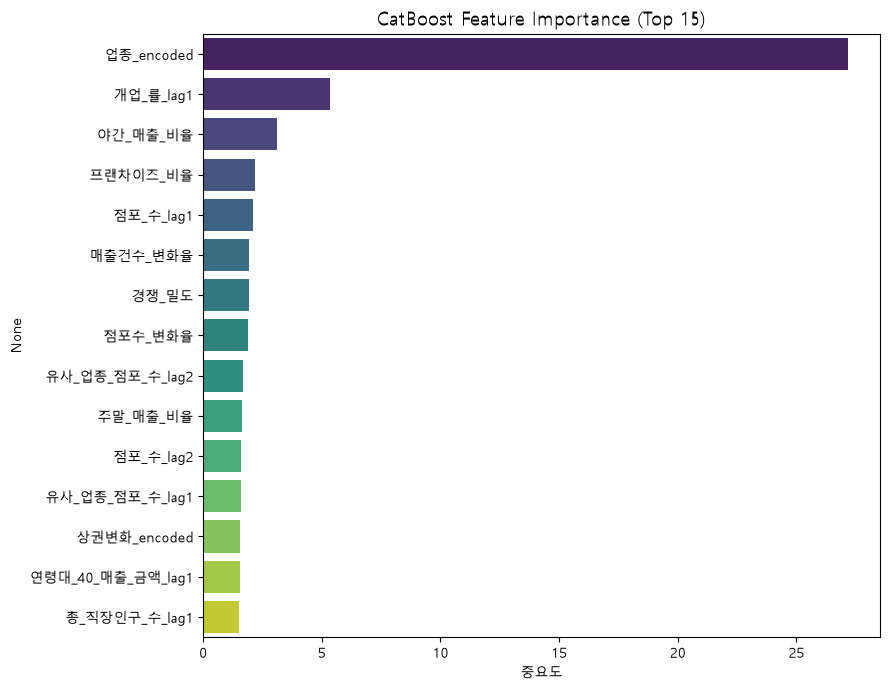

업종_encoded           27.16
개업_률_lag1             5.34
야간_매출_비율              3.11
프랜차이즈_비율              2.18
점포_수_lag1             2.09
매출건수_변화율              1.93
경쟁_밀도                 1.93
점포수_변화율               1.87
유사_업종_점포_수_lag2       1.69
주말_매출_비율              1.65
점포_수_lag2             1.60
유사_업종_점포_수_lag1       1.59
상권변화_encoded          1.54
연령대_40_매출_금액_lag1     1.53
총_직장인구_수_lag1         1.53
dtype: float64

In [5]:
importance = pd.Series(final_model.get_feature_importance(), index=X_train.columns)
top15 = importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=top15.values, y=top15.index, palette='viridis')
plt.title('CatBoost Feature Importance (Top 15)', fontsize=14)
plt.xlabel('중요도')
plt.tight_layout()
plt.show()

top15.round(2)

## 5. 혼동 행렬 (Confusion Matrix)

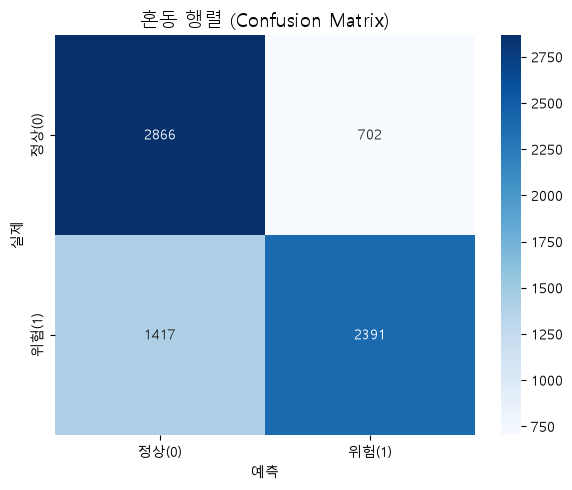

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['정상(0)', '위험(1)'],
            yticklabels=['정상(0)', '위험(1)'])
plt.title('혼동 행렬 (Confusion Matrix)', fontsize=14)
plt.ylabel('실제')
plt.xlabel('예측')
plt.tight_layout()
plt.show()

## 6. ROC Curve

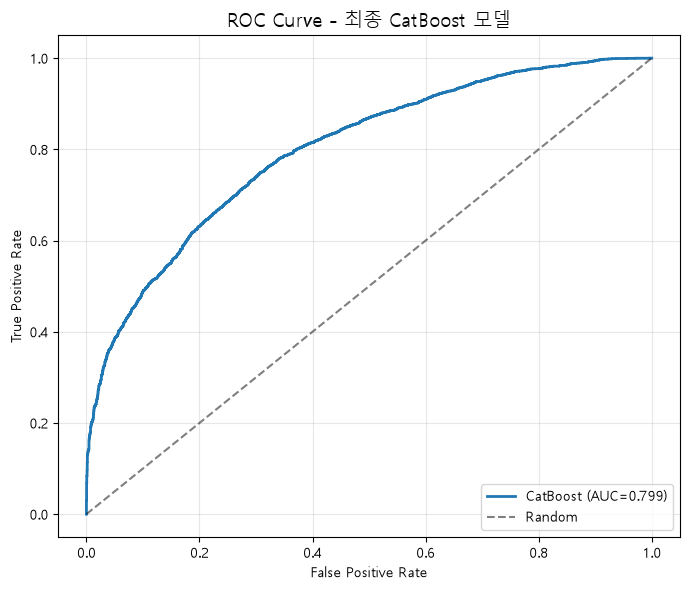

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'CatBoost (AUC={auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 최종 CatBoost 모델', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 정리

### 최종 모델: CatBoost + Optuna 튜닝

- **04**에서 5개 모델 중 CatBoost 선택 → **05**에서 Optuna로 하이퍼파라미터 최적화
- 검증셋 ROC-AUC 기준 20회 탐색으로 최적 파라미터 도출
- Feature Importance를 통해 폐업 위험의 주요 동인 확인

### 프로젝트 전체 흐름

| 노트북 | 내용 |
|--------|------|
| 00 | 8개 원본 데이터 병합 (137컬럼) |
| 01 | 탐색적 데이터 분석 (EDA) |
| 02 | 전처리 & 피처 엔지니어링 (66피처, 누수 방지) |
| 03 | 회귀 시도 → 분류 전환 근거 |
| 04 | 5개 분류 모델 비교 → CatBoost 선택 |
| 05 | CatBoost + Optuna 최종 모델 |